In [48]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math

In [ ]:
#Read in RTDose file
doseinfo = dcm.dcmread(r"C:\Users\bhaan\Downloads\Unrestricted beam plan\RD1.2.752.243.1.1.20250917161626831.9200.52685.dcm")
dose = doseinfo.DoseGridScaling * doseinfo.pixel_array
print(np.shape(dose))

(133, 119, 896)


Text(0.5, 1.0, 'Cross section of the beam with placement of the line profiles')

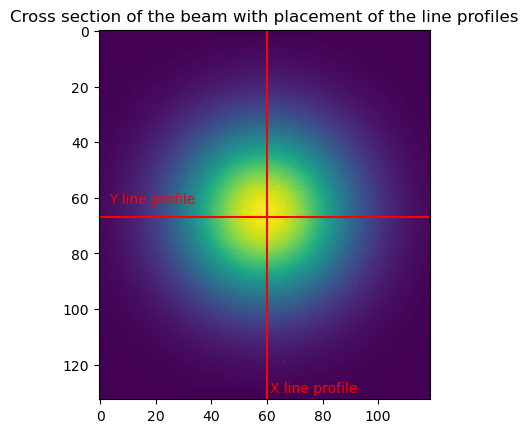

In [31]:
#Show one of the beam slices
plt.imshow(dose[:,:,5])
plt.plot([0, 118], [67, 67],'r')
plt.plot([60, 60], [0, 132],'r')
plt.text(3, 62, 'Y line profile', color='red')
plt.text(61, 130, 'X line profile', color='red')
plt.title('Cross section of the beam with placement of the line profiles')

In [ ]:
def LineProf(d, dim_slice, dim_prof):
    #inputs
    #d = np array of dose values from rtdose file
    #dim_slice = int, dimension along which to slice with 0 for x, 1 for y, 2 for z
    #dim_prof = int, dimension along which to take a line profile with 0 for x, 1 for y, 2 for z
    #dim_slice cannot be equal to dim_prof

    #Prepare fig
    fig = plt.figure()
    fig.set_figwidth(12)
    
    #Define places along beam where to slice
    zvalues = np.arange(1, dose.shape[dim_slice], 50)

    #Find middle, here we do the line profile
    M = math.ceil(dose.shape[dim_prof]/2)

    for z in zvalues:
        #get line profile from slice
        if dim_slice == 0:
            slice = d[z, :, :]
            if dim_prof == 1:
                prof = slice[M,:]
                txt = 'X line profiles along beam'
            if dim_prof == 2:
                prof = slice[:,M]
                txt = 'Y line profiles along beam'
        if dim_slice == 1:
            slice = d[:, z, :]
            if dim_prof == 0:
                prof = slice[M,:]
                txt = 'X line profiles along beam'
            if dim_prof == 2:
                prof = slice[:,M]
                txt = 'Y line profiles along beam'
        if dim_slice == 2:
            slice = d[:, :, z]
            if dim_prof == 0:
                prof = slice[M,:]
                txt = 'X line profiles along beam'
            if dim_prof == 1:
                prof = slice[:,M]
                txt = 'Y line profiles along beam'

        #Find maximum for normalisation if we're in the first iteration
        if z == 1:
            maximum = np.max(prof)

        #Normalise line profile
        prof = prof/maximum

        #Plot line profile
        lab = 'Beam location ' + str(z)
        plt.plot(prof, label=lab)

    #Customise plot
    plt.title(txt)
    plt.xlim([0, (len(prof) + 50)])
    plt.legend()

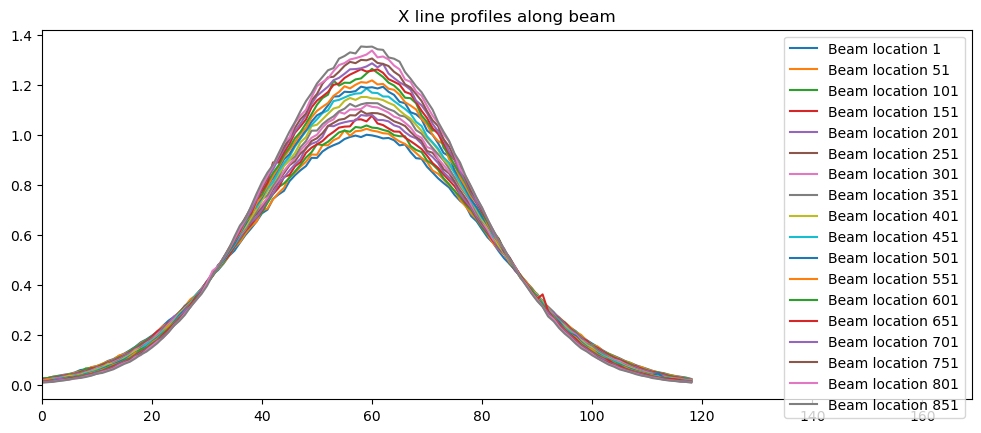

In [81]:
LineProf(dose, 2, 0)

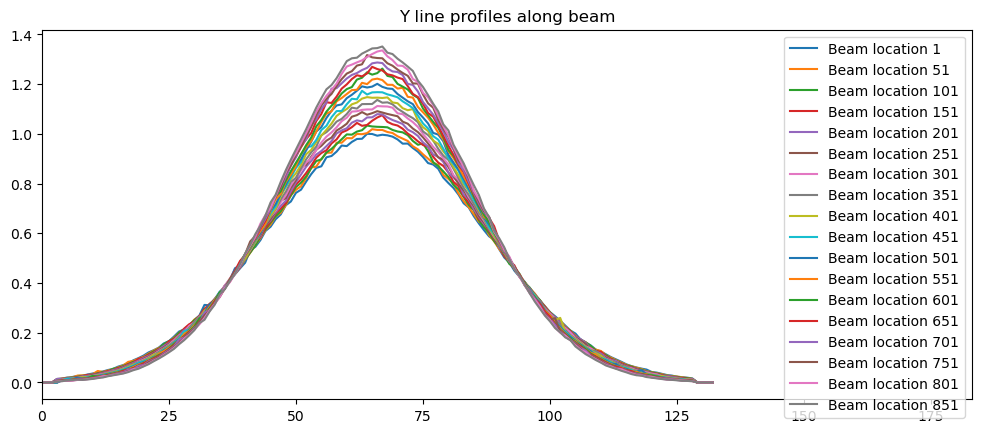

In [82]:
LineProf(dose, 2, 1)